<a href="https://colab.research.google.com/github/SilviaMaharjan/AI-ML_Workshops/blob/main/SilviaMaharjan_2408228_Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Worksheet 5**

# Exercise: Implement an End to End CNN Model for Image Classification Task.

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/AI and ML/FruitinAmazon.zip'
extract_to = '/content/drive/MyDrive/AI and ML'

os.makedirs(extract_to, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Zip file extracted successfully!")

Zip file extracted successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


**Task 1: Data Understanding and Visualization:**

Total Classes Found : 6
Class Names         : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


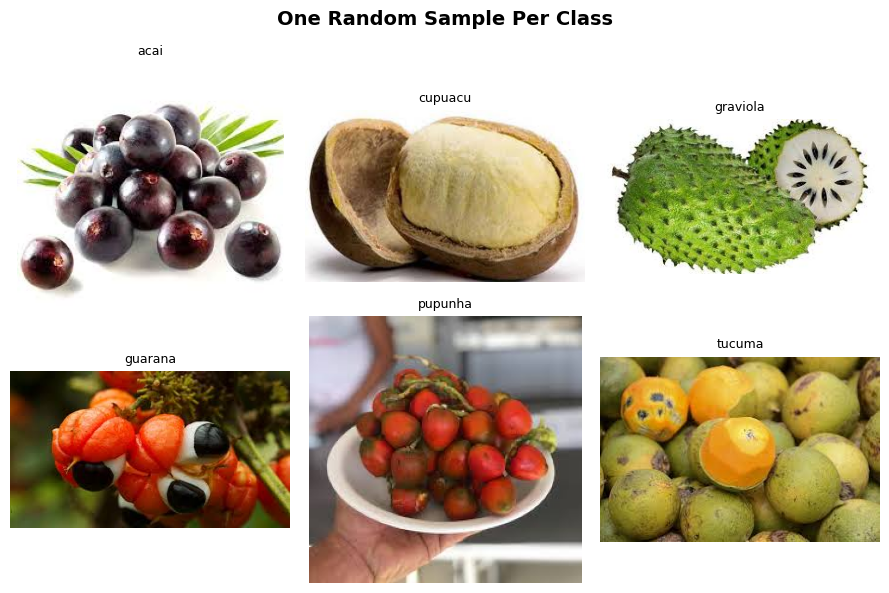


Observation:
- Each subdirectory represents a different fruit class.
- Images vary in colour, shape, size, and background.
- Some classes may look visually similar (e.g. apple vs tomato).
- The CNN will learn to distinguish these patterns during training.


In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt


TRAIN_DIR = "/content/drive/MyDrive/AI and ML/FruitinAmazon/train"

# Task 1.1 — Visualize one random image per class in a 2-row grid


# Get the list of class directories from the train folder
class_dirs = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])
print(f"Total Classes Found : {len(class_dirs)}")
print(f"Class Names         : {class_dirs}")

images = []
labels = []

# Select one image randomly from each class
for cls in class_dirs:
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_files = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))
    ]
    if img_files:
        chosen   = random.choice(img_files)
        img_path = os.path.join(cls_path, chosen)
        img      = Image.open(img_path).convert("RGB")
        images.append(img)
        labels.append(cls)

# Display images in a grid format with TWO ROWS
n    = len(images)
cols = (n + 1) // 2        # number of columns = ceil(n/2)

fig, axes = plt.subplots(2, cols, figsize=(cols * 3, 6))
axes = axes.flatten()

for i, (img, label) in enumerate(zip(images, labels)):
    axes[i].imshow(img)
    axes[i].set_title(label, fontsize=9)
    axes[i].axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("One Random Sample Per Class", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("class_samples.png", dpi=150)
plt.show()

# Observation
print("\nObservation:")
print("- Each subdirectory represents a different fruit class.")
print("- Images vary in colour, shape, size, and background.")
print("- Some classes may look visually similar (e.g. apple vs tomato).")
print("- The CNN will learn to distinguish these patterns during training.")


In [ ]:
# Task 1.2 — Check for Corrupted Images


print("\n--- Checking for Corrupted Images ---")

corrupted = []

for cls in os.listdir(TRAIN_DIR):
    cls_path = os.path.join(TRAIN_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    for fname in os.listdir(cls_path):
        image_path = os.path.join(cls_path, fname)
        try:
            with Image.open(image_path) as img:
                img.verify()    # verify checks integrity without full decode
        except (IOError, SyntaxError):
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")
            corrupted.append(image_path)

if not corrupted:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted)}")


--- Checking for Corrupted Images ---
No corrupted images found.


**Task 2: Loading and Preprocessing Image Data in keras:**

In [ ]:
import tensorflow as tf

# ---- PATHS ----
TRAIN_DIR = "/content/drive/MyDrive/AI and ML/FruitinAmazon/train"
TEST_DIR  = "/content/drive/MyDrive/AI and ML/FruitinAmazon/test"

# Hyperparameters
img_height       = 128
img_width        = 128
batch_size       = 32
validation_split = 0.2    # 80% train, 20% validation

# Normalization layer
rescale = tf.keras.layers.Rescaling(1.0 / 255)

# Training Dataset (80% of train folder)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = True,
    validation_split = validation_split,
    subset           = 'training',
    seed             = 123
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f"Classes     : {class_names}")
print(f"Num Classes : {num_classes}")

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))


# Validation Dataset (20% of train folder)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    labels           = 'inferred',
    label_mode       = 'int',
    image_size       = (img_height, img_width),
    interpolation    = 'nearest',
    batch_size       = batch_size,
    shuffle          = False,
    validation_split = validation_split,
    subset           = 'validation',
    seed             = 123
)
# Apply normalization
val_ds = val_ds.map(lambda x, y: (rescale(x), y))


# Test Dataset (separate test folder — no split)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (img_height, img_width),
    interpolation = 'nearest',
    batch_size    = batch_size,
    shuffle       = False
)
# Apply normalization
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# ---------------------------------------------------------------
# Cache and Prefetch for Performance
# ---------------------------------------------------------------
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# ---------------------------------------------------------------
# Print Summary
# ---------------------------------------------------------------
print(f"\nImage Size       : {img_height} x {img_width}")
print(f"Batch Size       : {batch_size}")
print(f"Validation Split : {validation_split}  (80% train / 20% val)")
print("Datasets ready   : train_ds  |  val_ds  |  test_ds")

Found 90 files belonging to 6 classes.
Using 72 files for training.
Classes     : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num Classes : 6
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.

Image Size       : 128 x 128
Batch Size       : 32
Validation Split : 0.2  (80% train / 20% val)
Datasets ready   : train_ds  |  val_ds  |  test_ds


**Task 3: Implement the CNN Architecture**

In [ ]:
import tensorflow as tf

img_height  = 128
img_width   = 128

print(f"Number of classes: {num_classes}")


# Build the CNN as per the worksheet specification

model = tf.keras.Sequential([

    # ----- Convolutional Block 1 -----
    tf.keras.layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        padding     = 'same',
        strides     = 1,
        activation  = 'relu',
        input_shape = (img_height, img_width, 3)
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ----- Convolutional Block 2 -----
    tf.keras.layers.Conv2D(
        filters     = 32,
        kernel_size = (3, 3),
        padding     = 'same',
        strides     = 1,
        activation  = 'relu'
    ),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # ----- Fully Connected Layers -----
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),   # Hidden Layer 1
    tf.keras.layers.Dense(64,  activation='relu'),   # Hidden Layer 2
    tf.keras.layers.Dense(num_classes, activation='softmax')  # Output Layer
])

# Print the model architecture
model.summary()

Number of classes: 6


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

**Task 4: Compile and Train the Model**

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.9705 - loss: 0.0513
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 933ms/step - accuracy: 0.9583 - loss: 0.0717 - val_accuracy: 0.8333 - val_loss: 1.5141
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.9097 - loss: 0.3921
Epoch 2: val_accuracy improved from 0.83333 to 0.94444, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 775ms/step - accuracy: 0.9167 - loss: 0.3151 - val_accuracy: 0.9444 - val_loss: 0.2893
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9797 - loss: 0.0536
Epoch 3: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 405ms/step - accuracy: 0.9861 - loss: 0.0558 - val_accuracy: 0.8333 - val_loss: 0.3756
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.9346 - loss: 0.1378
Epoch 4: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 398ms/step - accuracy: 0.9444 - loss: 0.1212 - val_accuracy: 0.7222 - val_loss: 0.8356
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.9797 - loss: 0.0882
Epoch 5: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step - accuracy: 0.9861 - loss: 0.0676 - val_accuracy: 0.8333 - val_loss: 0.6102
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 1.0000 - loss: 0.0502
Ep

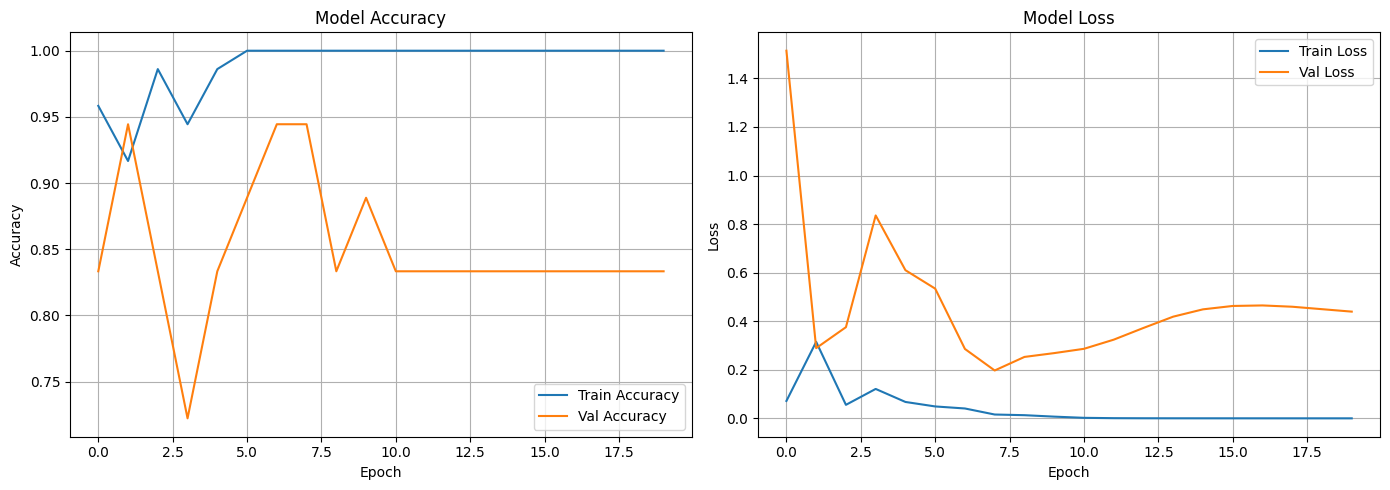

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Compile the Model

model.compile(
    optimizer = 'adam',                          # Adam optimizer
    loss      = 'sparse_categorical_crossentropy',  # integer labels → sparse
    metrics   = ['accuracy']
)


# Callbacks

# Saves the best model (highest val_accuracy) during training
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath        = 'best_model.h5',
    monitor         = 'val_accuracy',
    save_best_only  = True,
    verbose         = 1
)

# Stops training if val_loss does not improve for 20 epochs
early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor              = 'val_loss',
    patience             = 20,
    restore_best_weights = True,
    verbose              = 1
)

# Train the Model

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = 20,
    callbacks       = [checkpoint_cb, early_stop_cb]
)

print("\nTraining complete. Best model saved as best_model.h5")


# Plot Training vs Validation — Accuracy and Loss

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150)
plt.show()

**Task 5: Evaluate the Model**

In [ ]:
print("\n--- Model Evaluation on Test Set ---")

test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")



--- Model Evaluation on Test Set ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.5667 - loss: 1.1577

Test Loss     : 1.1577
Test Accuracy : 0.5667


**Task 6: Save and Load the Model**

In [ ]:
import tensorflow as tf

# Save the trained model to .h5 file

model.save('final_model.h5')
print("Model saved to: final_model.h5")

# Load the saved model back

loaded_model = tf.keras.models.load_model('final_model.h5')
print("Model loaded successfully from: final_model.h5")

# Re-evaluate the loaded model on the test set

print("\n--- Re-evaluation after Loading ---")
loss, acc = loaded_model.evaluate(test_ds, verbose=1)

print(f"\nLoaded Model — Test Loss     : {loss:.4f}")
print(f"Loaded Model — Test Accuracy : {acc:.4f}")


Model saved to: final_model.h5
Model loaded successfully from: final_model.h5

--- Re-evaluation after Loading ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 518ms/step - accuracy: 0.5667 - loss: 1.1577

Loaded Model — Test Loss     : 1.1577
Loaded Model — Test Accuracy : 0.5667


**Task 7: Predictions**

In [ ]:
import numpy as np
from sklearn.metrics import classification_report

class_names = ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

print(f"Classes    : {class_names}")
print(f"Num Classes: {len(class_names)}")

# Make predictions on all test images
all_preds  = []
all_labels = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

# Print Classification Report
print("\n--- Classification Report ---\n")
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names
))

Classes    : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num Classes: 6

--- Classification Report ---

              precision    recall  f1-score   support

        acai       0.36      1.00      0.53         5
     cupuacu       1.00      0.40      0.57         5
    graviola       1.00      0.40      0.57         5
     guarana       0.60      0.60      0.60         5
     pupunha       0.75      0.60      0.67         5
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.57        30
   macro avg       0.73      0.57      0.57        30
weighted avg       0.73      0.57      0.57        30

